<a href="https://colab.research.google.com/github/abusaleh917/Practice/blob/main/Assaignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment
| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.

#1. Load & Inspect Load CSV, print shape, missing values, and class distribution

In [16]:
# 1. Imports & Setup
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Data Loading


In [17]:
# 2. Data Loading
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks_Data_Science/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


Finding the Missing Values

In [18]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nAttack Ditected:\n", df['attack_detected'].value_counts().sort_index())
print("\nClass mapping: 0=Normal Ativity, 1=Attacked")

Missing values per column:
 encryption_used    1966
dtype: int64

Attack Ditected:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class mapping: 0=Normal Ativity, 1=Attacked


# 2. Preprocess	Drop irrelevant columns, fill missing values with median, scale features, split 80/20

In [19]:
df.drop(columns=['session_id'], inplace=True)

In [20]:
# Impute missing values for 'encryption_used' with its mode
# since it's a categorical feature and was not handled by median imputation.
if 'encryption_used' in df.columns and df['encryption_used'].isnull().any():
    mode_encryption_used = df['encryption_used'].mode()[0]
    df['encryption_used'].fillna(mode_encryption_used, inplace=True)

# Handle missing numeric values (if any remain) with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=['attack_detected'])
y = df_encoded['attack_detected']

X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


/tmp/ipykernel_2018/1811527793.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['encryption_used'].fillna(mode_encryption_used, inplace=True)


# 3. EDA	Bar chart of class distribution + top-10 feature correlations

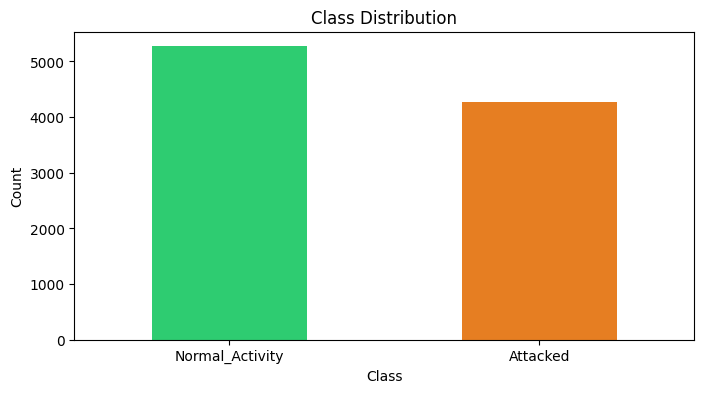

In [21]:
labels = ['Normal_Activity', 'Attacked']

counts = df['attack_detected'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e67e22']
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()


/tmp/ipykernel_2018/2963339058.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_correlations.values, y=top_10_correlations.index, palette='viridis', ax=ax)


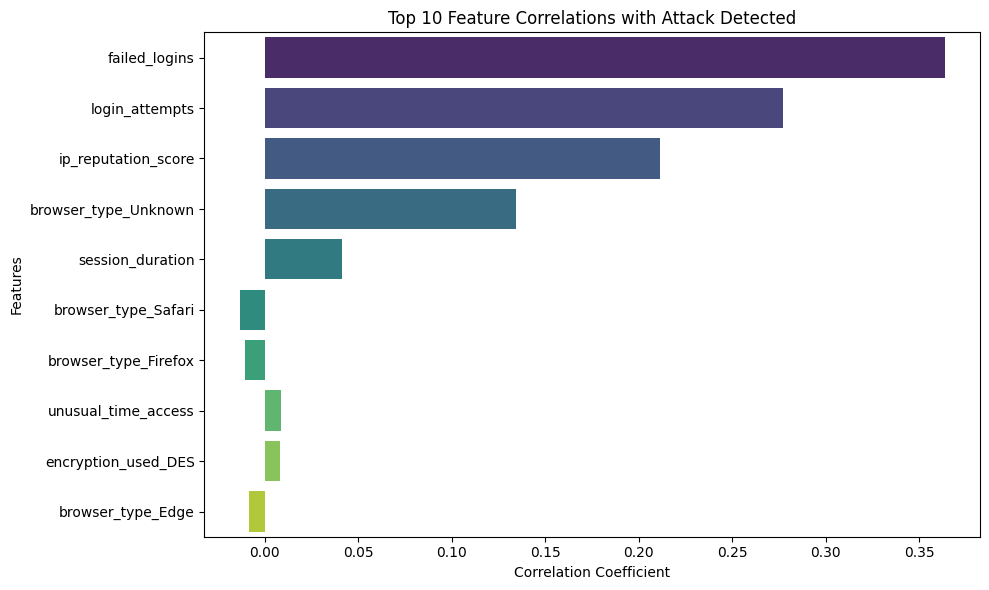

In [22]:
# Calculate correlations with the target variable 'attack_detected'
correlations = df_encoded.corr()['attack_detected'].sort_values(ascending=False)

# Exclude the target variable itself from the list
correlations = correlations.drop('attack_detected')

# Get the top 10 most correlated features (absolute values)
top_10_correlated_features = correlations.abs().nlargest(10).index.tolist()

# Filter the original correlations to only include the top 10 features
top_10_correlations = correlations[top_10_correlated_features]

# Plotting the top 10 feature correlations
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_10_correlations.values, y=top_10_correlations.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Feature Correlations with Attack Detected')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Features')
plt.tight_layout()
plt.show()

#4. Train Models	Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1

In [23]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8155  Precision = 0.8169 Recall = 0.8155 F1=0.8158
KNN (k=5): Acc=0.8029  Precision = 0.8137 Recall = 0.8029 F1=0.7982
Logistic Reg: Acc=0.7495  Precision = 0.7488 Recall = 0.7495 F1=0.7487


#5. Depth Tuning	Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart

           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8952     0.9090  0.8952    0.8930
15           0.8800     0.8868  0.8800    0.8783
20           0.8595     0.8607  0.8595    0.8587
None         0.8155     0.8169  0.8155    0.8158


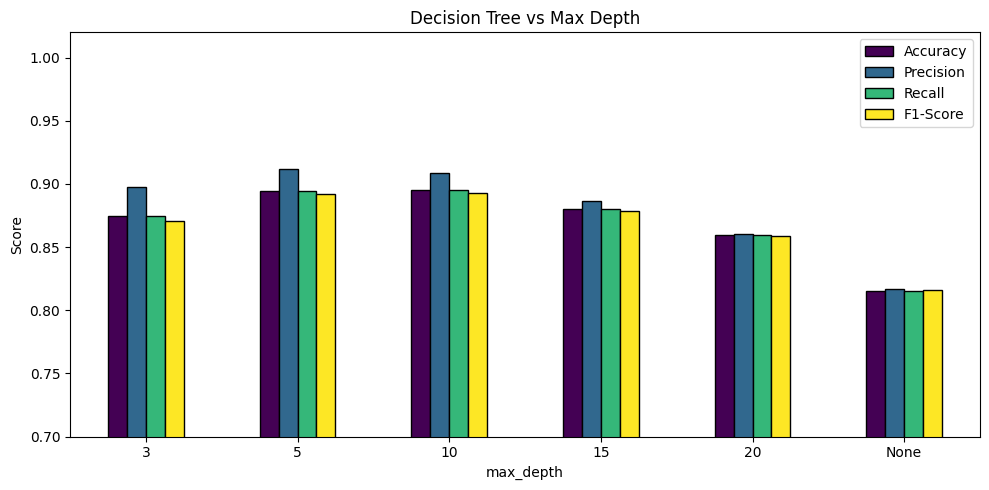

In [24]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

#6. Evaluate	Classification reports + 1×3 confusion matrix grid + model comparison bar chart

In [26]:
#Evaluate Classification
target_names = ['Normal Activity', 'Attacked']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
                 precision    recall  f1-score   support

Normal Activity     0.8463    0.8142    0.8300      1055
       Attacked     0.7805    0.8171    0.7984       853

       accuracy                         0.8155      1908
      macro avg     0.8134    0.8157    0.8142      1908
   weighted avg     0.8169    0.8155    0.8158      1908


KNN (k=5)
                 precision    recall  f1-score   support

Normal Activity     0.7692    0.9194    0.8377      1055
       Attacked     0.8686    0.6589    0.7493       853

       accuracy                         0.8029      1908
      macro avg     0.8189    0.7891    0.7935      1908
   weighted avg     0.8137    0.8029    0.7982      1908


Logistic Reg
                 precision    recall  f1-score   support

Normal Activity     0.7620    0.7953    0.7783      1055
       Attacked     0.7323    0.6928    0.7120       853

       accuracy                         0.7495      1908
      macro avg     0.7472    0.7441    

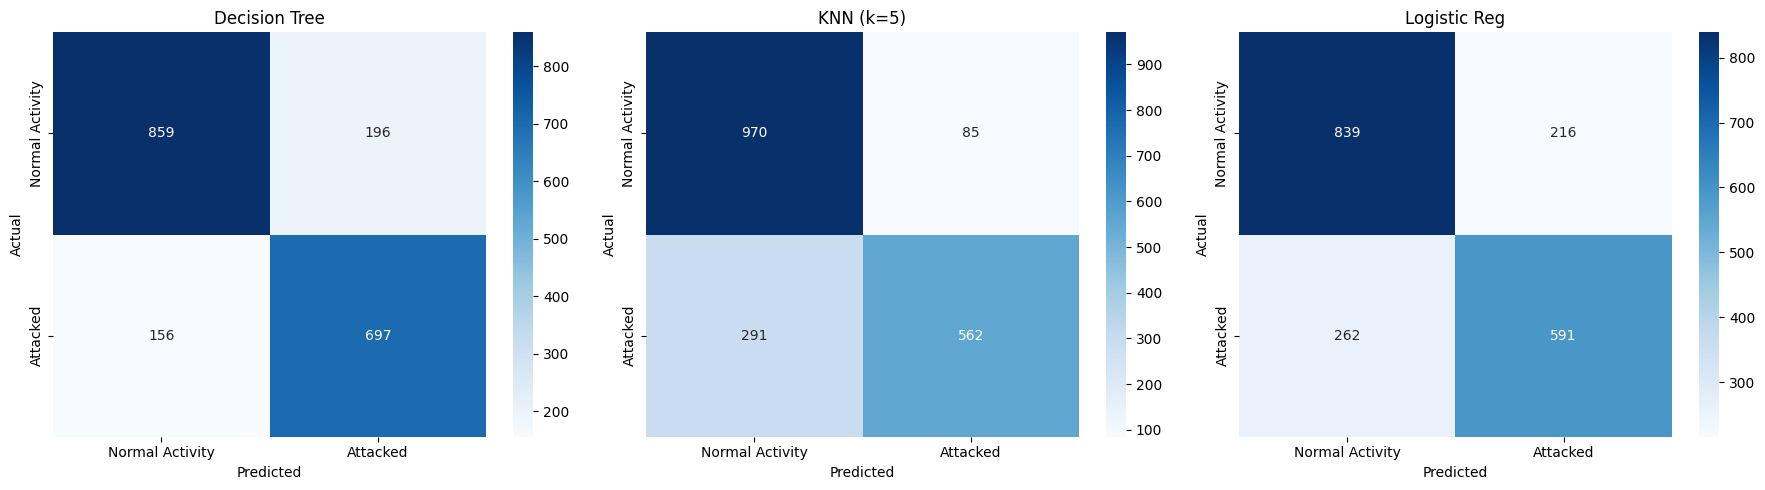

In [27]:
#Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

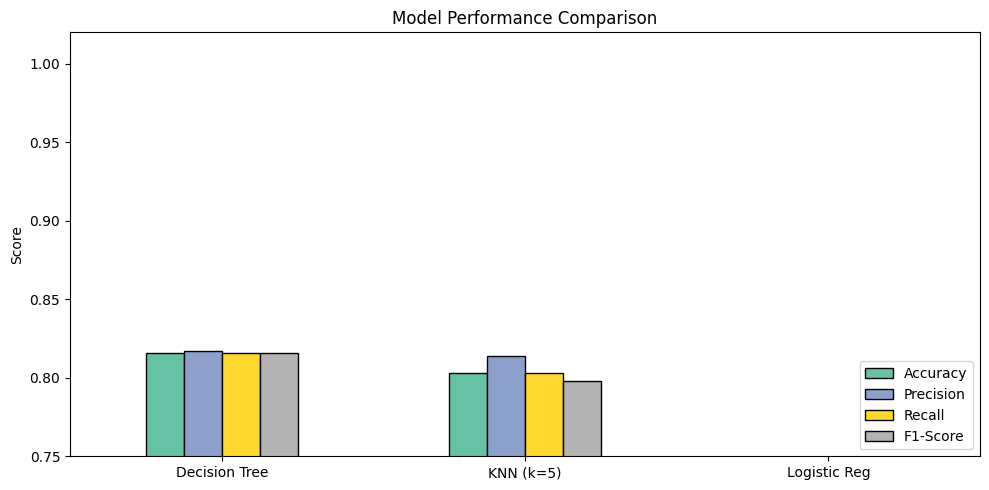


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8155     0.8169  0.8155    0.8158
KNN (k=5)        0.8029     0.8137  0.8029    0.7982
Logistic Reg     0.7495     0.7488  0.7495    0.7487


In [28]:
# Model Comparision bar chart
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))